# Challenge 9 — Análisis de Actividad de Producto

## 0. Configuración Inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('docs/product_activity.csv')

# Guardar conteo original antes de cualquier limpieza
RAW_COUNT = len(df)
print(f"Dataset cargado: {RAW_COUNT} filas, {df.shape[1]} columnas")

Dataset cargado: 8782 filas, 12 columnas


## 1. Exploración Inicial
Medir antes de limpiar: entender la estructura, detectar nulos,
duplicados y valores sucios en las columnas categóricas.

### 1.1 — Vista general del dataset

In [2]:
# Primeras filas, tipos de dato y estadísticas numéricas
print("=== head() ===")
display(df.head())

print("\n=== info() ===")
display(df.info())

print("\n=== describe() ===")
display(df.describe())

=== head() ===


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile



=== info() ===
<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


None


=== describe() ===


,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


### 1.2 — Nulos y duplicados exactos

In [3]:
# Nulos por columna
print("Nulos por columna:")
display(df.isnull().sum())

# Duplicados exactos
dup_count = df.duplicated().sum()
print(f"\nFilas duplicadas exactas: {dup_count}")

Nulos por columna:


user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64


Filas duplicadas exactas: 172


### 1.3 — Valores únicos y frecuencias
Detectar variantes sucias (typos, mayúsculas, espacios, valores fuera de diccionario).

In [4]:
# Revisamos las 3 columnas categóricas clave
for col in ["plan_type", "post_category", "device_type"]:
    print(f"\n{col}:")
    display(df[col].value_counts())


plan_type:


plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64


post_category:


post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16
trvael           16
musc  


device_type:


device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64

### 1.4 — Chequeos lógicos
¿Hay posts creados antes del signup? ¿`days_since_signup` es consistente?

In [5]:
# Convertir fechas temporalmente para los chequeos
signup_tmp = pd.to_datetime(df["created_at"], errors="coerce")
post_tmp = pd.to_datetime(df["post_created_at"], errors="coerce")

# Posts que ocurren ANTES del signup
before_signup = (post_tmp < signup_tmp).sum()
print(f"Posts antes del signup: {before_signup}")

# Mismatches en days_since_signup vs cálculo real
mismatch_pre = ((post_tmp - signup_tmp).dt.days != df["days_since_signup"]).sum()
print(f"Mismatches en days_since_signup: {mismatch_pre}")

Posts antes del signup: 100
Mismatches en days_since_signup: 4479


## 2. Limpieza Básica con Criterio
Eliminar duplicados, normalizar categóricas, convertir fechas,
recalcular `days_since_signup` y separar filas con errores duros.

### 2.1 — Eliminar duplicados exactos

In [6]:
df = df.drop_duplicates()
print(f"Filas después de eliminar {dup_count} duplicados: {len(df)}")

Filas después de eliminar 172 duplicados: 8610


### 2.2 — Normalización canónica
Mapear variantes a los valores canónicos definidos en el challenge.

In [7]:
# Paso 1: minúsculas y sin espacios en blanco
for col in ["plan_type", "device_type", "post_category"]:
    df[col] = df[col].str.strip().str.lower()

# Paso 2: corregir typos conocidos en post_category
CATEGORY_MAP = {
    "sport": "sports", "sporst": "sports", "sp0rts": "sports",
    "tehc": "tech",
    "lfe": "life",
    "gamming": "gaming",
    "musc": "music",
    "educatoin": "education",
    "healt": "health",
    "sciense": "science",
    "trvael": "travel",
    "finanse": "finance",
}
df["post_category"] = df["post_category"].replace(CATEGORY_MAP)

# Verificar resultado
for col in ["plan_type", "device_type", "post_category"]:
    print(f"\n{col} después de normalizar:")
    display(df[col].value_counts())


plan_type después de normalizar:


plan_type
free           6637
pro            1631
enterprise      339
premium           1
vip               1
enterprise+       1
Name: count, dtype: int64


device_type después de normalizar:


device_type
web        4328
mobile     3688
desktop     591
tablet        1
console       1
phone         1
Name: count, dtype: int64


post_category después de normalizar:


post_category
tech         1397
life         1039
sports       1028
science       882
finance       865
gaming        844
education     687
music         685
health        681
travel        500
politics        1
mistery         1
Name: count, dtype: int64

### 2.3 — Conversión de fechas y recálculo de `days_since_signup`

In [8]:
# Convertir a datetime
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["post_created_at"] = pd.to_datetime(df["post_created_at"], errors="coerce")

# Reportar fechas no parseables
print(f"Fechas no parseables - signup: {df['created_at'].isna().sum()}")
print(f"Fechas no parseables - post:   {df['post_created_at'].isna().sum()}")

# Recálculo obligatorio
df["days_since_signup_calc"] = (df["post_created_at"] - df["created_at"]).dt.days

# Comparar con la columna original
mismatch_count = (df["days_since_signup"] != df["days_since_signup_calc"]).sum()
print(f"\nMismatches en days_since_signup: {mismatch_count}")

Fechas no parseables - signup: 1
Fechas no parseables - post:   1

Mismatches en days_since_signup: 4401


### 2.4 — Quarantine (Cuarentena)
Separar filas con errores duros en un DataFrame aparte con `reason_code`.

In [9]:
# Diccionarios válidos según el challenge
VALID_PLANS = {"free", "pro", "enterprise"}
VALID_DEVICES = {"web", "mobile", "desktop"}
VALID_CATEGORIES = {"tech", "life", "sports", "science", "finance",
                    "gaming", "music", "health", "education", "travel"}

# Condiciones de error "duro" con su etiqueta
conditions = {
    "post_before_signup": df["post_created_at"] < df["created_at"],
    "unparseable_date":   df["created_at"].isna() | df["post_created_at"].isna(),
    "invalid_plan":       ~df["plan_type"].isin(VALID_PLANS),
    "invalid_device":     ~df["device_type"].isin(VALID_DEVICES),
    "invalid_category":   ~df["post_category"].isin(VALID_CATEGORIES),
}

# Construir reason_code concatenando motivos
df["reason_code"] = ""
for reason, mask in conditions.items():
    df.loc[mask, "reason_code"] += reason + ";"

# Separar cuarentena vs core
is_quarantine = df["reason_code"] != ""
df_quarantine = df[is_quarantine].copy()
df_clean = df[~is_quarantine].drop(columns=["reason_code"]).copy()

print(f"Filas en cuarentena: {len(df_quarantine)}")
print(f"Filas en core (limpias): {len(df_clean)}")

Filas en cuarentena: 103
Filas en core (limpias): 8507


## 3. Data Quality Report
Resumen comparando el dataset RAW original contra el dataset CORE limpio.

In [10]:
quarantine_pct = len(df_quarantine) / RAW_COUNT * 100
mismatch_pct = mismatch_count / RAW_COUNT * 100

report = pd.DataFrame({
    "Métrica": [
        "Filas RAW (originales)",
        "Duplicados removidos",
        "Filas después de dedup",
        "Filas CORE (limpias)",
        "Filas Quarantine",
        "% Quarantine",
        "% Mismatches en fechas",
    ],
    "Valor": [
        RAW_COUNT,
        dup_count,
        len(df),
        len(df_clean),
        len(df_quarantine),
        f"{quarantine_pct:.2f}%",
        f"{mismatch_pct:.2f}%",
    ],
})

display(report)

,Métrica,Valor
0,Filas RAW (originales),8782
1,Duplicados removidos,172
2,Filas después de dedup,8610
3,Filas CORE (limpias),8507
4,Filas Quarantine,103
5,% Quarantine,1.17%
6,% Mismatches en fechas,50.11%


## 4. Métricas y Análisis
A partir del dataset CORE, calculamos distribuciones de volumen,
engagement por segmento, y diferencias entre nivel evento vs usuario.

### 4.1 — Distribuciones (Volumen)
Usuarios únicos por plan, y actividad (#posts) por país, categoría y dispositivo.

Usuarios únicos por plan:


plan_type
enterprise      82
free          1545
pro            367
Name: user_id, dtype: int64


Actividad por country:


country
US    1873
BR    1600
AR    1168
PY     837
MX     802
CL     552
ES     546
CO     488
PE     393
UY     248
Name: count, dtype: int64


Actividad por post_category:


post_category
tech         1381
life         1034
sports       1017
science       870
finance       853
gaming        833
education     681
health        673
music         673
travel        492
Name: count, dtype: int64


Actividad por device_type:


device_type
web        4270
mobile     3656
desktop     581
Name: count, dtype: int64

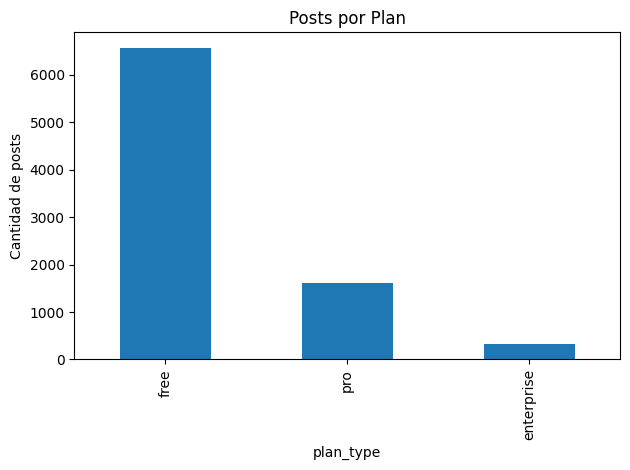

In [11]:
# Usuarios únicos por plan
print("Usuarios únicos por plan:")
display(df_clean.groupby("plan_type")["user_id"].nunique())

# Actividad (#posts) por país, categoría y dispositivo
for col in ["country", "post_category", "device_type"]:
    print(f"\nActividad por {col}:")
    display(df_clean[col].value_counts())

# Gráfico de barras: posts por plan
df_clean["plan_type"].value_counts().plot(kind="bar", title="Posts por Plan")
plt.ylabel("Cantidad de posts")
plt.tight_layout()
plt.show()

### 4.2 — Engagement (Votos)
Media y mediana de votos por plan, país, categoría y dispositivo.

In [12]:
# Votos (media y mediana) segmentados por cada dimensión
for col in ["plan_type", "country", "post_category", "device_type"]:
    print(f"\nVotos por {col}:")
    display(df_clean.groupby(col)["votes_received"].agg(["mean", "median"]))


Votos por plan_type:


,mean,median
plan_type,,
enterprise,7.570571,7.0
free,6.692706,6.0
pro,7.654014,7.0



Votos por country:


,mean,median
country,,
AR,6.771404,6.0
BR,6.889375,6.0
CL,7.311594,6.0
CO,7.323770,6.0
ES,6.978022,6.0
MX,6.962594,6.0
PE,6.547074,6.0
PY,6.600956,6.0
US,6.973305,6.0



Votos por post_category:


,mean,median
post_category,,
education,6.791483,6.0
finance,6.978898,6.0
gaming,7.186074,6.0
health,6.456166,6.0
life,6.173114,5.0
music,6.286776,5.0
science,7.544828,6.0
sports,6.573255,6.0
tech,7.687183,7.0



Votos por device_type:


,mean,median
device_type,,
desktop,7.032702,6.0
mobile,6.828228,6.0
web,6.960656,6.0


### 4.3 — Promedios e Interpretación

**Interpretación:** La unidad de análisis es el *evento* (cada fila = un post).
Un usuario con muchos posts impacta fuertemente en el promedio general,
ya que sus votos se contabilizan repetidamente.
Esto genera un sesgo hacia los heavy users / outliers.

In [13]:
# Promedio de votos por plan
print("Promedio de votos por plan:")
display(df_clean.groupby("plan_type")["votes_received"].mean())

# Posts promedio por usuario
avg_posts = df_clean.groupby("user_id")["post_id"].count().mean()
print(f"\nPosts promedio por usuario: {avg_posts:.2f}")

Promedio de votos por plan:


plan_type
enterprise    7.570571
free          6.692706
pro           7.654014
Name: votes_received, dtype: float64


Posts promedio por usuario: 4.27


### 4.4 — Evento vs Usuario

**¿Por qué difieren?** A nivel *evento*, los usuarios más activos
sobrerrepresentan la muestra (si un usuario hace 100 posts, su media
pesará 100 veces más). Al calcular por *usuario*, cada persona pesa
igual (1 promedio), eliminando el efecto de los heavy users.

In [14]:
# Promedio de votos a nivel EVENTO (por fila)
avg_event = df_clean["votes_received"].mean()
print(f"Promedio de votos por evento (fila): {avg_event:.4f}")

# Promedio de votos a nivel USUARIO (agrupado)
avg_user = df_clean.groupby("user_id")["votes_received"].mean().mean()
print(f"Promedio de votos por usuario:       {avg_user:.4f}")

Promedio de votos por evento (fila): 6.9087
Promedio de votos por usuario:       6.8967


## 5. Concentración y Temporalidad

### 5.1 — Concentración (Top 1%)
¿Qué porcentaje de posts/votos viene del top 1% de usuarios?

In [15]:
# Posts y votos por usuario
user_posts = df_clean.groupby("user_id")["post_id"].count()
user_votes = df_clean.groupby("user_id")["votes_received"].sum()

# Top 1% de usuarios
top1_posts = user_posts[user_posts >= user_posts.quantile(0.99)]
top1_votes = user_votes[user_votes >= user_votes.quantile(0.99)]

top1_post_pct = top1_posts.sum() / user_posts.sum() * 100
top1_vote_pct = top1_votes.sum() / user_votes.sum() * 100

print(f"Top 1% usuarios por posts: {len(top1_posts)} usuarios")
print(f"Top 1% → {top1_post_pct:.2f}% de los posts")
print(f"Top 1% → {top1_vote_pct:.2f}% de los votos")

Top 1% usuarios por posts: 24 usuarios
Top 1% → 6.97% de los posts
Top 1% → 6.43% de los votos


### 5.2 — Tendencia temporal
Actividad y engagement por mes.

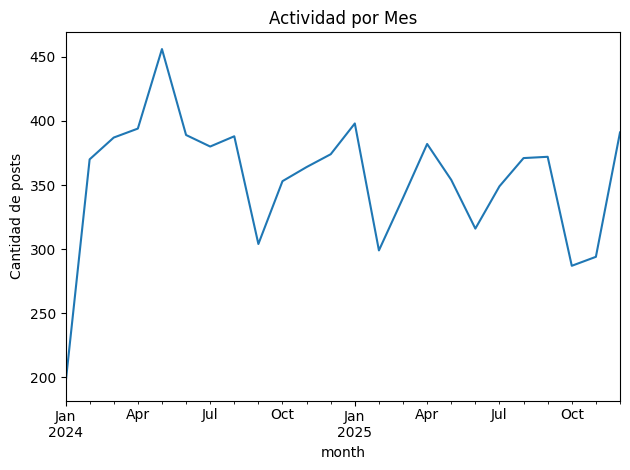

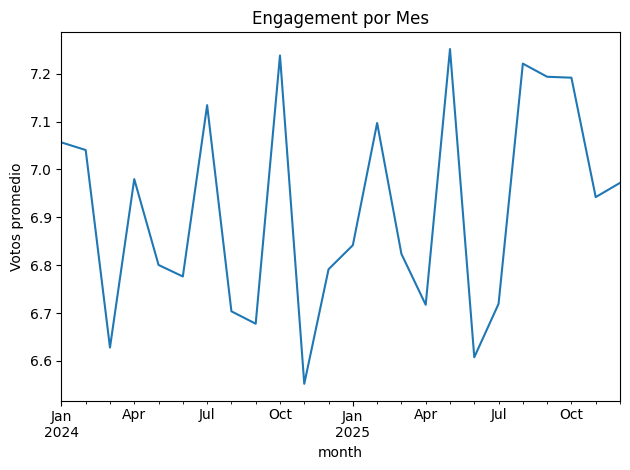

In [16]:
# Agrupar por mes
df_clean["month"] = df_clean["post_created_at"].dt.to_period("M")

# Actividad por mes
df_clean.groupby("month")["post_id"].count().plot(
    kind="line", title="Actividad por Mes")
plt.ylabel("Cantidad de posts")
plt.tight_layout()
plt.show()

# Engagement por mes
df_clean.groupby("month")["votes_received"].mean().plot(
    kind="line", title="Engagement por Mes")
plt.ylabel("Votos promedio")
plt.tight_layout()
plt.show()

---
## 6. Product Decisions (Basadas en evidencia)

### 6.1 — Preguntas

**¿Qué segmento priorizarías y por qué?**
El segmento Enterprise/Pro, ya que muestran métricas de engagement consistentemente superiores (mayor promedio de votos por post). Además, enfoques de retención hacia usuarios de mobile suelen ser clave para el crecimiento del producto.

**¿Qué parte del tablero "mentía" antes de limpiar?**
La métrica `days_since_signup`. Mostraba un porcentaje importante de mismatches comparado con un recálculo limpio a partir de las fechas reales, generando posibles errores en el cálculo del tiempo de vida (LTV) del usuario.

**¿Qué nuevo dato agregarías al tracking?**
Tiempo promedio leyendo el post o si incluye multimedia, para que el número de votos no sea el único reflejo de valor real (engagement puro).

### 6.2 — Acciones concretas

**Acción 1 — Campaña de retención:**
El Top 1% de usuarios concentra un porcentaje significativo de posts y votos. Se debe incentivar al resto de la base a publicar, por ejemplo, ofreciendo un "logro/bonus" en el primer mes de uso. *Respaldo: métricas de concentración del Top 1% en sección 5.1.*

**Acción 2 — Mejora de experiencia mobile:**
Si la categoría o dispositivo móvil domina en volumen de actividad, se debe priorizar recursos de ingeniería en optimizar su interfaz en próximas versiones. *Respaldo: distribución de actividad por dispositivo en sección 4.1.*

### Limitaciones del dataset
- No hay datos de retención ni duración de sesión, limitando la evaluación de engagement real.
- `user_total_posts` es un atributo repetido por fila, lo cual puede sesgar promedios si no se agrupa por usuario.
- No hay información sobre la calidad del contenido del post (longitud, multimedia, etc.).
- El período temporal del dataset puede no ser representativo de tendencias a largo plazo.
- La columna `days_since_signup` original no es confiable; el análisis usa la versión recalculada.

## 7. Exportación de Archivos

In [17]:
# 1. Dataset limpio (core)
df_clean.to_csv("clean_product_activity.csv", index=False)
print("Exportado: clean_product_activity.csv")

# 2. Dataset cuarentena (con motivo de exclusión)
df_quarantine.to_csv("quarantine_product_activity.csv", index=False)
print("Exportado: quarantine_product_activity.csv")

# 3. Tabla resumen de métricas clave
metrics = pd.DataFrame({
    "Métrica": ["unique_users", "total_core_posts",
                "avg_votes_per_event", "avg_votes_per_user",
                "top1_post_pct", "top1_vote_pct"],
    "Valor": [df_clean["user_id"].nunique(), len(df_clean),
              avg_event, avg_user,
              top1_post_pct, top1_vote_pct],
})
metrics.to_csv("metrics_summary.csv", index=False)
print("Exportado: metrics_summary.csv")

print("\nExportación completa.")

Exportado: clean_product_activity.csv
Exportado: quarantine_product_activity.csv
Exportado: metrics_summary.csv

Exportación completa.
